# Lab 3 Solutions: PyTorch for Cat vs Dog Faces

These are worked solutions for the PyTorch lab. The code below fills in each scaffolded task from the student notebook, including the simple CNN used for the main classifier.

Set `STUDENT_ID` in the first code cell. Each notebook uses it as the random seed for sampling, split suggestions, and visualization so every student gets a reproducible variant.


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from lab_utils.visualization import (
    extract_feature_maps,
    plot_feature_maps_like_reference,
    plot_training_history,
    show_tensor_batch,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data" / "cats_dogs_faces_small").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "cats_dogs_faces_small"
METADATA_PATH = DATA_ROOT / "metadata.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABELS = ("cat", "dog")
SPLITS = ("train", "val", "test")
STUDENT_ID = 10422021  # Replace with your own student ID.
SEED = int(STUDENT_ID)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
NUMPY_PRED_PATH = ARTIFACT_DIR / f"lab1_numpy_predictions_{STUDENT_ID}.csv"

def student_index(length: int, offset: int = 0) -> int:
    if length <= 0:
        raise ValueError("Cannot choose an index from an empty collection.")
    return int((SEED + offset) % length)

def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            label_dir = data_root / split / label
            for path in sorted(label_dir.glob("*.jpg")) + sorted(label_dir.glob("*.png")):
                with Image.open(path) as image:
                    image = image.convert("RGB")
                    width, height = image.size
                rows.append(
                    {
                        "filepath": str(path.relative_to(data_root)),
                        "label": label,
                        "split": split,
                        "width": width,
                        "height": height,
                    }
                )
    return pd.DataFrame(rows)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the prepared subset at data/cats_dogs_faces_small/."
    )

if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
else:
    df = build_metadata_from_folders(DATA_ROOT)

print(f"Student ID seed: {STUDENT_ID}")
print(df.head())
print(df["split"].value_counts())


Student ID seed: 10422021
                 filepath label  split  width  height  mean_intensity  \
0  train/cat/cat_0000.jpg   cat  train     64      64        0.584909   
1  train/cat/cat_0001.jpg   cat  train     64      64        0.403741   
2  train/cat/cat_0002.jpg   cat  train     64      64        0.450109   
3  train/cat/cat_0003.jpg   cat  train     64      64        0.452337   
4  train/cat/cat_0004.jpg   cat  train     64      64        0.427763   

                                         source_path  
0  /Users/fuisloy/lab/data/raw/animal-faces/afhq/...  
1  /Users/fuisloy/lab/data/raw/animal-faces/afhq/...  
2  /Users/fuisloy/lab/data/raw/animal-faces/afhq/...  
3  /Users/fuisloy/lab/data/raw/animal-faces/afhq/...  
4  /Users/fuisloy/lab/data/raw/animal-faces/afhq/...  
split
train    420
val       90
test      90
Name: count, dtype: int64


## Question 1: Turn string labels into integer labels

Create:

- a dictionary `label_to_index`
- a new column `label_id`

Use `cat -> 0` and `dog -> 1`.


In [24]:
label_to_index = {"cat": 0, "dog": 1}
df = df.copy()
df["label_id"] = df["label"].map(label_to_index)

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

print(label_to_index)
print(train_df[["filepath", "label", "label_id"]].head())

assert set(label_to_index.keys()) == {"cat", "dog"}, "Both classes should appear in the mapping."


{'cat': 0, 'dog': 1}
                 filepath label  label_id
0  train/cat/cat_0000.jpg   cat         0
1  train/cat/cat_0001.jpg   cat         0
2  train/cat/cat_0002.jpg   cat         0
3  train/cat/cat_0003.jpg   cat         0
4  train/cat/cat_0004.jpg   cat         0


## Question 2: Build a dataset that returns tensors

Complete:

- `image_to_tensor`
- `CatsDogsDataset.__getitem__`

Your dataset should return:

- an image tensor with shape `(3, 64, 64)`
- an integer label tensor


In [25]:
def image_to_tensor(path: Path) -> torch.Tensor:
    with Image.open(path) as image:
        image = image.convert("RGB")
        array = np.asarray(image, dtype=np.float32) / 255.0
    return torch.from_numpy(array).permute(2, 0, 1)

class CatsDogsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, data_root: Path):
        self.frame = frame.reset_index(drop=True)
        self.data_root = data_root

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image_tensor = image_to_tensor(self.data_root / row["filepath"])
        label_tensor = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return image_tensor, label_tensor

train_dataset = CatsDogsDataset(train_df, DATA_ROOT)
first_image, first_label = train_dataset[0]
print(first_image.shape, first_image.dtype, first_label)


torch.Size([3, 64, 64]) torch.float32 tensor(0)


## Question 3: Create DataLoaders

Build three DataLoaders:

- training loader with `shuffle=True`
- validation loader with `shuffle=False`
- test loader with `shuffle=False`

Use a batch size of `32`.


In [26]:
BATCH_SIZE = 32
train_loader_generator = torch.Generator().manual_seed(SEED)

val_dataset = CatsDogsDataset(val_df, DATA_ROOT)
test_dataset = CatsDogsDataset(test_df, DATA_ROOT)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_loader_generator,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

train_loader, val_loader, test_loader


(<torch.utils.data.dataloader.DataLoader at 0x11ced1fd0>,
 <torch.utils.data.dataloader.DataLoader at 0x11ced1490>)

## Question 4: Inspect one mini-batch

Pull one batch from the training loader and verify:

- image batch shape
- label batch shape
- image dtype
- label dtype


Image batch: torch.Size([32, 3, 64, 64]) torch.float32
Label batch: torch.Size([32]) torch.int64


(<Figure size 1000x600 with 8 Axes>,
 array([[<Axes: title={'center': 'dog'}>, <Axes: title={'center': 'cat'}>,
         <Axes: title={'center': 'dog'}>, <Axes: title={'center': 'dog'}>],
        [<Axes: title={'center': 'dog'}>, <Axes: title={'center': 'dog'}>,
         <Axes: title={'center': 'cat'}>, <Axes: title={'center': 'cat'}>]],
       dtype=object))

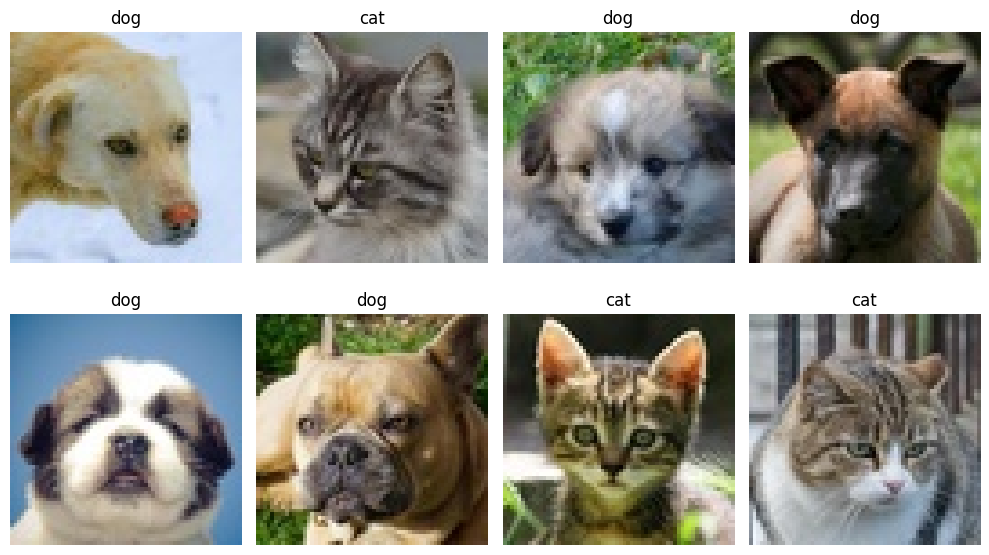

In [27]:
if train_loader is None:
    raise ValueError("Complete Question 3 before inspecting a batch.")

batch_images, batch_labels = next(iter(train_loader))

print("Image batch:", batch_images.shape, batch_images.dtype)
print("Label batch:", batch_labels.shape, batch_labels.dtype)

assert batch_images.ndim == 4, "Batches of images should have shape (B, C, H, W)."
assert batch_images.shape[1] == 3, "Color images should have 3 channels."

show_tensor_batch(
    batch_images[:8].cpu().numpy(),
    batch_labels[:8].cpu().numpy(),
    class_names=LABELS,
    max_items=8,
    ncols=4,
)


## Question 5: Define a simple CNN classifier

Complete the model below.

Suggested architecture:

- stage 1: `Conv2d(3, 16, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- stage 2: `Conv2d(16, 32, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- classifier: `Flatten` -> `Linear(32 * 16 * 16, 64)` -> `ReLU` -> `Linear(64, 2)`


In [28]:
class CatsDogsSimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stage1(x)
        x = self.stage2(x)
        return self.classifier(x)


model = CatsDogsSimpleCNN()
example_logits = model(batch_images[:4])
print(example_logits.shape)

assert example_logits.shape == (4, 2), "The classifier should output two logits per image."


torch.Size([4, 2])


## Question 6: Set up the training ingredients

Choose:

- a device (`cuda` if available, otherwise `cpu`)
- a loss function
- an optimizer

Use `CrossEntropyLoss` and `Adam` for this lab.


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Using device:", device)


Using device: cpu


## Question 7: Complete one training epoch

Fill in the missing logic for:

- zeroing gradients
- forward pass
- loss computation
- backward pass
- optimizer step
- batch accuracy tracking


In [30]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples
    return average_loss, average_accuracy


## Question 8: Evaluate the model and compare it with the NumPy baseline

Complete the evaluation loop, train for a few epochs, and compare test accuracy with Lab 1.

Reflection prompts:

1. Did the simple CNN outperform the NumPy baseline?
2. Did the model start to overfit?
3. What would you try next: horizontal flips, more filters, one more conv block, or longer training?


Epoch 1: train_loss=0.7222, train_acc=0.512, val_loss=0.6901, val_acc=0.511
Epoch 2: train_loss=0.6864, train_acc=0.571, val_loss=0.6719, val_acc=0.722
Epoch 3: train_loss=0.6454, train_acc=0.762, val_loss=0.6041, val_acc=0.733
Epoch 4: train_loss=0.5163, train_acc=0.798, val_loss=0.5546, val_acc=0.689
Epoch 5: train_loss=0.4322, train_acc=0.767, val_loss=0.4083, val_acc=0.856
Test accuracy (PyTorch CNN): 0.844
Test accuracy (NumPy baseline): 0.433


[{'epoch': 1,
  'train_loss': 0.7221822534288679,
  'train_acc': 0.5119047619047619,
  'val_loss': 0.6900888469484118,
  'val_acc': 0.5111111111111111},
 {'epoch': 2,
  'train_loss': 0.6863783705802191,
  'train_acc': 0.5714285714285714,
  'val_loss': 0.6718677388297187,
  'val_acc': 0.7222222222222222},
 {'epoch': 3,
  'train_loss': 0.6454379337174552,
  'train_acc': 0.7619047619047619,
  'val_loss': 0.6040724198023478,
  'val_acc': 0.7333333333333333},
 {'epoch': 4,
  'train_loss': 0.5163283200491042,
  'train_acc': 0.7976190476190477,
  'val_loss': 0.5545501228835847,
  'val_acc': 0.6888888888888889},
 {'epoch': 5,
  'train_loss': 0.4322194224312192,
  'train_acc': 0.7666666666666667,
  'val_loss': 0.4083491000864241,
  'val_acc': 0.8555555555555555}]

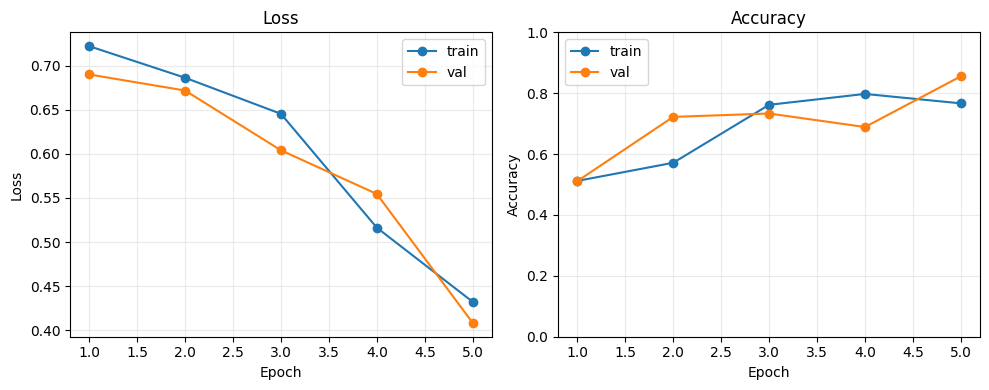

In [31]:
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            predictions = logits.argmax(dim=1)
            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples
    return average_loss, average_accuracy

EPOCHS = 5
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )
    print(
        f"Epoch {epoch}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
    )

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test accuracy (PyTorch CNN): {test_acc:.3f}")

if NUMPY_PRED_PATH.exists():
    numpy_pred_df = pd.read_csv(NUMPY_PRED_PATH)
    numpy_baseline_acc = numpy_pred_df["correct_numpy"].mean()
    print(f"Test accuracy (NumPy baseline): {numpy_baseline_acc:.3f}")
else:
    print(f"NumPy baseline predictions not found. Run Lab 1 with STUDENT_ID={STUDENT_ID} if you want a direct comparison.")

plot_training_history(history)

history


## Optional Visualization: Feature Maps Like the AlexNet Notebook

The main lab now uses a simple CNN, so we can visualize feature maps from the trained model directly.

The visualization utility is intentionally styled like the tiled activation-grid view from the referenced AlexNet notebook:

- one tile per channel
- `viridis` colormap
- light gaps between maps
- fixed `vmin` and `vmax` controls so maps are easier to compare

We will inspect stage-1 and stage-2 activations for one student-specific training image.


Feature-map example for student 10422021: dog -> train/dog/dog_0011.jpg


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Simple CNN feature maps after stage 2'}>,
 array([[[0.132268, 0.655014, 0.519661],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         ...,
         [0.12478 , 0.640461, 0.527068],
         [0.19109 , 0.708366, 0.482284],
         [0.14021 , 0.665859, 0.513427]],
 
        [[0.134692, 0.658636, 0.517649],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         ...,
         [0.24607 , 0.73891 , 0.452024],
         [0.232815, 0.732247, 0.459277],
         [0.166383, 0.690856, 0.496502]],
 
        [[0.130067, 0.651384, 0.521608],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         ...,
         [0.166383, 0.690856, 0.496502],
         [0.146616, 0.67305 , 0.508936],
         [0.185783, 0.704891, 0.485273]],
 
        ...,
 
        [[0.122312, 0.633153, 0.530398],
         [0.232815, 0.732247, 0.459277],
        

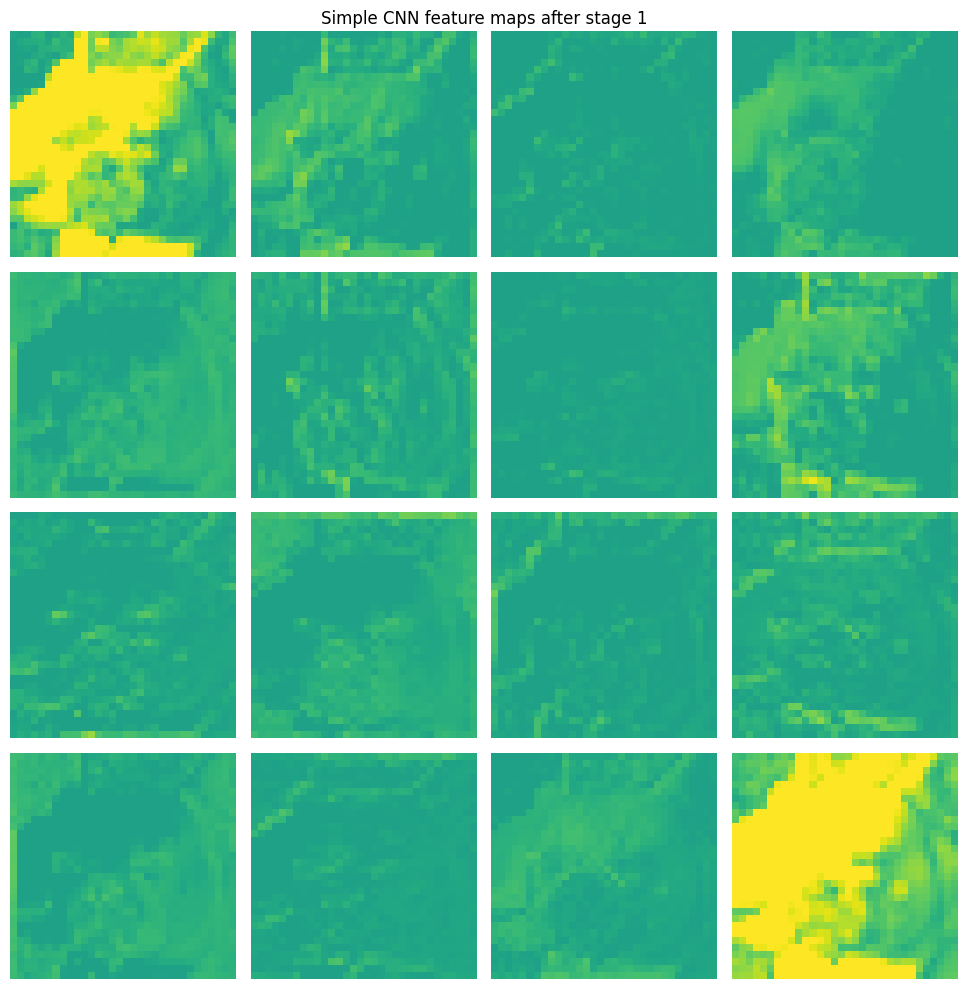

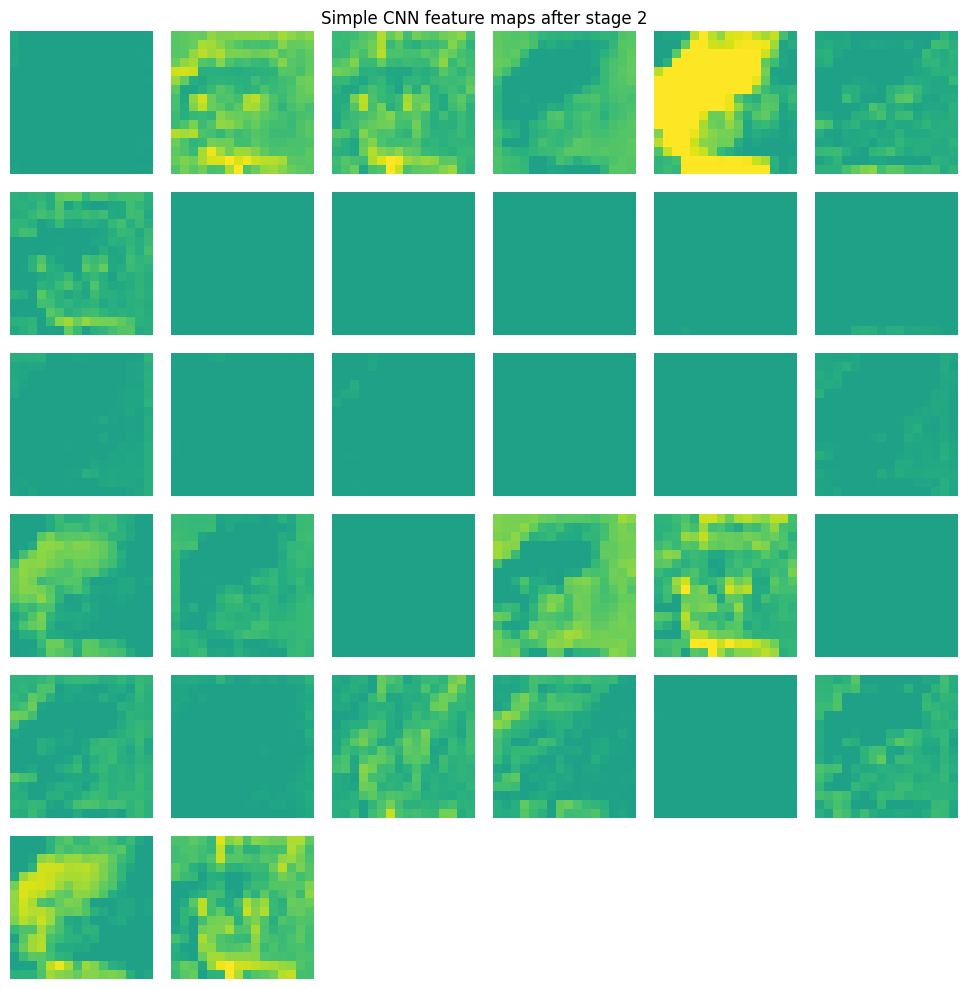

In [32]:
if device is None:
    raise ValueError("Complete Questions 5-8 before visualizing feature maps.")

feature_map_device = device if device is not None else torch.device("cpu")
model = model.to(feature_map_device)
model.eval()

feature_map_index = student_index(len(train_dataset), offset=500)
feature_map_row = train_df.iloc[feature_map_index]
example_image, _ = train_dataset[feature_map_index]
print(
    f"Feature-map example for student {STUDENT_ID}: "
    f"{feature_map_row['label']} -> {feature_map_row['filepath']}"
)

stage1_maps = extract_feature_maps(
    model.stage1,
    example_image,
    device=feature_map_device,
)
stage2_maps = extract_feature_maps(
    nn.Sequential(model.stage1, model.stage2),
    example_image,
    device=feature_map_device,
)

plot_feature_maps_like_reference(
    stage1_maps,
    title="Simple CNN feature maps after stage 1",
    figsize=(10, 10),
)

plot_feature_maps_like_reference(
    stage2_maps,
    title="Simple CNN feature maps after stage 2",
    figsize=(10, 10),
)


## Optional extension

If you finish early, try one of these:

- increase the filters from `16, 32` to `24, 48`
- add one more convolution block before the classifier
- compare stage-1 and stage-2 feature maps for the same image
- add random horizontal flips to the training data

Then record which change helped validation accuracy most and how the feature maps changed.
